In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet

conn = duckdb.connect('../ecommerce.db')

df = conn.execute("""
    SELECT order_date, total_revenue, total_orders
    FROM analytics.mart_daily_revenue
    ORDER BY order_date
""").df()

conn.close()

df['order_date'] = pd.to_datetime(df['order_date'])

# Remove the June 30 spike we noticed earlier — it's a data artifact
df = df[df['order_date'] < '2024-06-30']

print(f"Date range : {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Total days : {len(df)}")
print(f"Avg daily revenue : ₹{df['total_revenue'].mean():,.0f}")
df.tail()

Date range : 2022-01-12 to 2024-06-29
Total days : 783
Avg daily revenue : ₹17,609


,order_date,total_revenue,total_orders
778,2024-06-25,45780.19,7
779,2024-06-26,14002.30,5
780,2024-06-27,25259.15,7
781,2024-06-28,8933.55,4
782,2024-06-29,14397.14,4


In [2]:
# Prophet requires columns named exactly 'ds' and 'y'
prophet_df = df[['order_date', 'total_revenue']].rename(columns={
    'order_date':    'ds',
    'total_revenue': 'y'
})

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
)

model.fit(prophet_df)
print("Model fitted successfully")

21:43:20 - cmdstanpy - INFO - Chain [1] start processing
21:43:23 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully


In [3]:
future   = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Pull out just the forecast period
forecast_only = forecast[forecast['ds'] > prophet_df['ds'].max()][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].copy()

forecast_only.columns = ['date', 'predicted', 'lower_bound', 'upper_bound']
forecast_only[['predicted', 'lower_bound', 'upper_bound']] = \
    forecast_only[['predicted', 'lower_bound', 'upper_bound']].round(2)

print("30-day revenue forecast:")
print(forecast_only.to_string(index=False))

30-day revenue forecast:
      date  predicted  lower_bound  upper_bound
2024-06-30   26120.07     10942.42     40439.27
2024-07-01   26235.04     12192.55     38910.96
2024-07-02   24985.99     11377.86     38688.71
2024-07-03   27702.83     14754.42     41646.98
2024-07-04   24105.37     10395.30     38403.74
2024-07-05   25177.72     11523.72     39469.45
2024-07-06   27165.74     13763.09     40669.70
2024-07-07   28087.94     14699.23     41599.38
2024-07-08   28403.60     14871.70     41718.07
2024-07-09   27344.48     14326.87     40377.38
2024-07-10   30237.88     16220.13     44054.21
2024-07-11   26801.11     13642.59     41077.31
2024-07-12   28015.87     14262.22     41338.10
2024-07-13   30125.80     16009.28     43607.84
2024-07-14   31147.35     17402.84     45758.24
2024-07-15   31537.96     18027.68     44814.62
2024-07-16   30527.81     15606.38     43152.03
2024-07-17   33442.86     19729.79     46812.04
2024-07-18   29999.39     15737.46     43925.01
2024-07-19   31

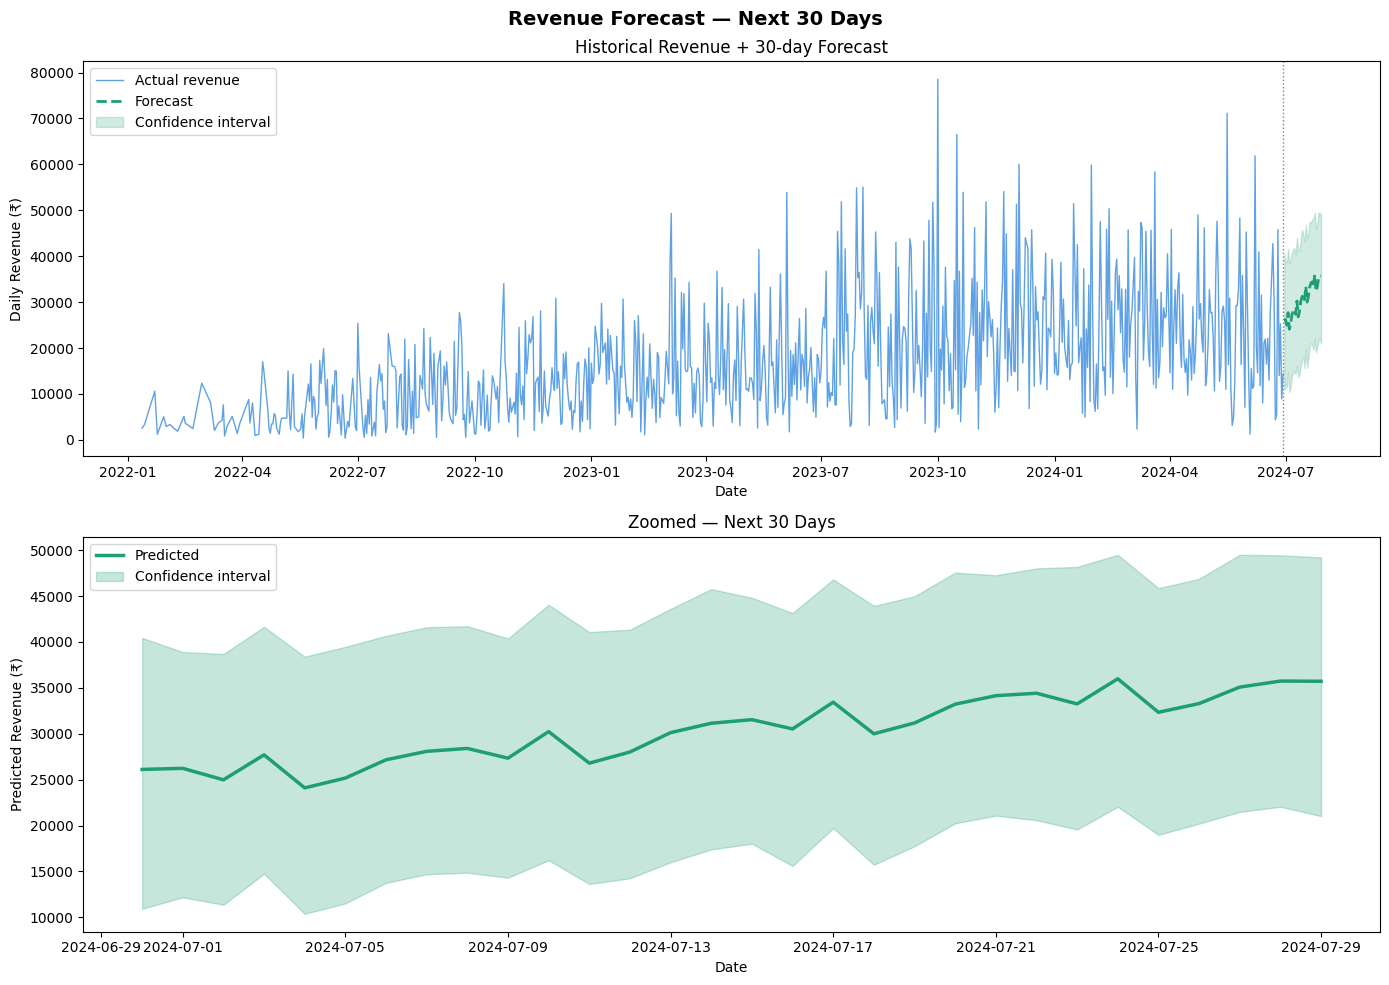

Chart saved to reports/revenue_forecast.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Revenue Forecast — Next 30 Days', fontsize=14, fontweight='bold')

# Full history + forecast
ax1 = axes[0]
ax1.plot(prophet_df['ds'], prophet_df['y'],
         color='#378ADD', linewidth=1, label='Actual revenue', alpha=0.8)
ax1.plot(forecast_only['date'], forecast_only['predicted'],
         color='#1D9E75', linewidth=2, label='Forecast', linestyle='--')
ax1.fill_between(forecast_only['date'],
                 forecast_only['lower_bound'],
                 forecast_only['upper_bound'],
                 alpha=0.2, color='#1D9E75', label='Confidence interval')
ax1.axvline(prophet_df['ds'].max(), color='gray', linestyle=':', linewidth=1)
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Revenue (₹)')
ax1.set_title('Historical Revenue + 30-day Forecast')
ax1.legend()

# Forecast only — zoomed in
ax2 = axes[1]
ax2.plot(forecast_only['date'], forecast_only['predicted'],
         color='#1D9E75', linewidth=2.5, label='Predicted')
ax2.fill_between(forecast_only['date'],
                 forecast_only['lower_bound'],
                 forecast_only['upper_bound'],
                 alpha=0.25, color='#1D9E75', label='Confidence interval')
ax2.set_xlabel('Date')
ax2.set_ylabel('Predicted Revenue (₹)')
ax2.set_title('Zoomed — Next 30 Days')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/revenue_forecast.png")

In [5]:
next_7  = forecast_only.head(7)
next_30 = forecast_only

print("=" * 50)
print("REVENUE FORECAST SUMMARY")
print("=" * 50)
print(f"\nNext 7 days:")
print(f"  Total predicted  : ₹{next_7['predicted'].sum():>12,.0f}")
print(f"  Daily average    : ₹{next_7['predicted'].mean():>12,.0f}")
print(f"  Lower bound      : ₹{next_7['lower_bound'].sum():>12,.0f}")
print(f"  Upper bound      : ₹{next_7['upper_bound'].sum():>12,.0f}")

print(f"\nNext 30 days:")
print(f"  Total predicted  : ₹{next_30['predicted'].sum():>12,.0f}")
print(f"  Daily average    : ₹{next_30['predicted'].mean():>12,.0f}")
print(f"  Lower bound      : ₹{next_30['lower_bound'].sum():>12,.0f}")
print(f"  Upper bound      : ₹{next_30['upper_bound'].sum():>12,.0f}")
print("=" * 50)

REVENUE FORECAST SUMMARY

Next 7 days:
  Total predicted  : ₹     181,493
  Daily average    : ₹      25,928
  Lower bound      : ₹      84,949
  Upper bound      : ₹     278,229

Next 30 days:
  Total predicted  : ₹     911,555
  Daily average    : ₹      30,385
  Lower bound      : ₹     500,567
  Upper bound      : ₹   1,322,832


In [6]:
conn = duckdb.connect('../ecommerce.db')

conn.execute("DROP TABLE IF EXISTS analytics.mart_revenue_forecast")
conn.execute("""
    CREATE TABLE analytics.mart_revenue_forecast AS
    SELECT
        CAST(ds AS DATE)              AS forecast_date,
        ROUND(yhat, 2)                AS predicted_revenue,
        ROUND(yhat_lower, 2)          AS lower_bound,
        ROUND(yhat_upper, 2)          AS upper_bound,
        CASE
            WHEN ds <= (SELECT MAX(order_date)
                        FROM analytics.mart_daily_revenue)
            THEN 'actual'
            ELSE 'forecast'
        END                           AS record_type
    FROM forecast
""")

print("Saved to analytics.mart_revenue_forecast")
print()
print("Record type breakdown:")
print(conn.execute("""
    SELECT record_type,
           COUNT(*) as days,
           ROUND(AVG(predicted_revenue), 0) as avg_daily_revenue
    FROM analytics.mart_revenue_forecast
    GROUP BY record_type
""").df().to_string(index=False))

conn.close()

Saved to analytics.mart_revenue_forecast

Record type breakdown:
record_type  days  avg_daily_revenue
   forecast    29            30532.0
     actual   784            17629.0
